In [ ]:
from google.colab import drive
drive.mount('/content/drive')

fl_file_path = '/content/drive/MyDrive/FL.csv'
sl_file_path = '/content/drive/MyDrive/SL.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from IPython.display import Markdown

# Section 1: Fitts Law

In [3]:
fl_df = pd.read_csv(fl_file_path)
fl_df

,Unnamed: 0,distance,width,movement_time
0,5945,210,10,1136
1,2870,120,14,631
2,3477,210,10,1128
3,2492,60,10,553
4,5628,60,14,423
...,...,...,...,...
3697,3542,120,6,1015
3698,3173,40,10,408
3699,5588,160,14,519
3700,776,120,18,816


In [4]:
fl_df.drop(columns=['Unnamed: 0'], inplace=True)
fl_df

,distance,width,movement_time
0,210,10,1136
1,120,14,631
2,210,10,1128
3,60,10,553
4,60,14,423
...,...,...,...
3697,120,6,1015
3698,40,10,408
3699,160,14,519
3700,120,18,816


In [5]:
fl_df['ID'] = np.log2((fl_df['distance']/fl_df['width']) + 1)
fl_df

,distance,width,movement_time,ID
0,210,10,1136,4.459432
1,120,14,631,3.258734
2,210,10,1128,4.459432
3,60,10,553,2.807355
4,60,14,423,2.402098
...,...,...,...,...
3697,120,6,1015,4.392317
3698,40,10,408,2.321928
3699,160,14,519,3.635589
3700,120,18,816,2.938599


In [6]:
grouped_ID_df = fl_df.groupby('ID')['movement_time'].mean().reset_index()
grouped_ID_df

,ID,movement_time
0,1.584963,452.797872
1,1.688056,448.551020
2,1.947533,489.815534
3,2.000000,517.298969
4,2.115477,518.650000
5,2.247928,534.400000
6,2.321928,547.113208
7,2.369234,542.040000
8,2.402098,551.094737
9,2.584963,616.245098


In [7]:
X = grouped_ID_df['ID'].values.reshape(-1,1)
y = grouped_ID_df['movement_time'].values
print(X)
print(y)

[[1.5849625 ]
 [1.68805599]
 [1.94753258]
 [2.        ]
 [2.11547722]
 [2.24792751]
 [2.32192809]
 [2.36923381]
 [2.40209844]
 [2.5849625 ]
 [2.66837851]
 [2.80735492]
 [2.93859946]
 [3.08746284]
 [3.169925  ]
 [3.25873427]
 [3.30580843]
 [3.37503943]
 [3.45943162]
 [3.52356196]
 [3.63558857]
 [3.66296501]
 [3.70043972]
 [3.7548875 ]
 [4.        ]
 [4.08746284]
 [4.39231742]
 [4.45943162]
 [4.76818432]
 [4.79007693]
 [5.169925  ]]
[ 452.79787234  448.55102041  489.81553398  517.29896907  518.65
  534.4         547.11320755  542.04        551.09473684  616.24509804
  594.29591837  644.85645933  653.81775701  663.43069307  704.2745098
  709.53333333  727.92708333  728.55769231  712.43442623  768.20952381
  800.65740741  799.47311828  794.8         790.53535354  838.74285714
  881.4516129   919.80952381  925.05357143 1037.95495495  998.24271845
 1064.59482759]


In [8]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [9]:
a = model.intercept_
b = model.coef_[0]
print("a:",a)
print("b:",b)

a: 136.76422192675875
b: 178.66005403991014


In [10]:
grouped_ID_df['predicted_MT'] = model.predict(X)
grouped_ID_df

,ID,movement_time,predicted_MT
0,1.584963,452.797872,419.933708
1,1.688056,448.551020,438.352397
2,1.947533,489.815534,484.710498
3,2.000000,517.298969,494.084330
4,2.115477,518.650000,514.715496
5,2.247928,534.400000,538.379073
6,2.321928,547.113208,551.600021
7,2.369234,542.040000,560.051662
8,2.402098,551.094737,565.923260
9,2.584963,616.245098,598.593762


In [11]:
r_squared_value = r2_score(y,grouped_ID_df['predicted_MT'])
print("R-squared Value:", r_squared_value)
root_mean_squared_error_value = math.sqrt(mean_squared_error(y,grouped_ID_df['predicted_MT']))
print("Root Mean Squared Error:", root_mean_squared_error_value)

R-squared Value: 0.9895372888310685
Root Mean Squared Error: 17.291401328954215


In [12]:
fl_result_data = {
    'a': [a],
    'b': [b],
    'R²': [r_squared_value],
    'RMSE': [root_mean_squared_error_value]
}
fl_result_df = pd.DataFrame(fl_result_data)
print(fl_result_df)
fl_result_df.to_csv('/content/drive/MyDrive/results_FL.csv', index=False)

            a           b        R²       RMSE
0  136.764222  178.660054  0.989537  17.291401


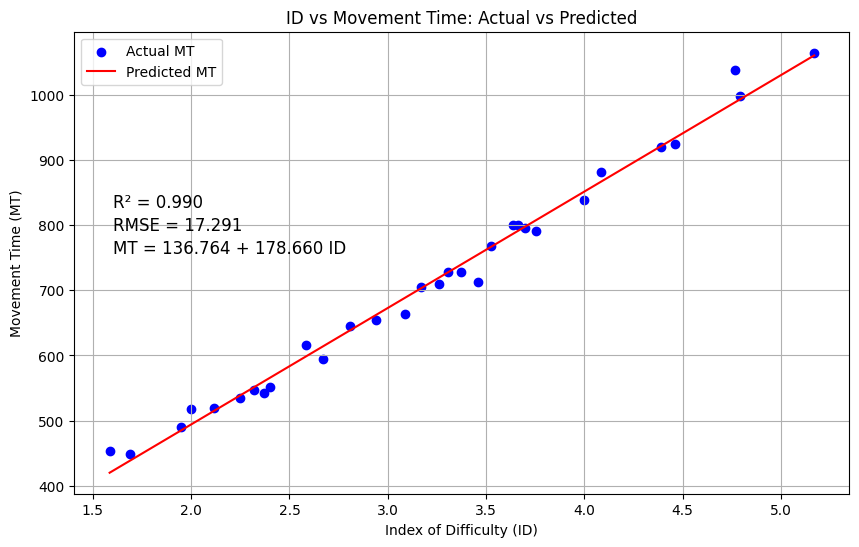

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(X,y, label="Actual MT", color="Blue")

plt.plot(X,grouped_ID_df['predicted_MT'], label="Predicted MT", color = "Red")
plt.xlabel("Index of Difficulty (ID)")
plt.ylabel("Movement Time (MT)")
plt.title("ID vs Movement Time: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.text(0.05, 0.65, f"R² = {r_squared_value:.3f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.05, 0.60, f"RMSE = {root_mean_squared_error_value:.3f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.05, 0.55, f"MT = {a:.3f} + {b:.3f} ID", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')


plt.show()

### Final Observation: Fitts Law

The Linear Regression model gave the values of a=136.76 and 𝑏=178.66. The R² or the coefficient of determination is 0.99 which indicates that the model explains approximately 99% of the variance in the data and the RMSE is 17.29 and that is a reasonably small error relative to the scale of the dependent variable. Hence we can say that Linear Regression model is effective in modeling Fitts Law.

# Section 2: Steering Law

In [14]:
sl_df = pd.read_csv(sl_file_path)
sl_df

,Unnamed: 0,distance,width,movement_time
0,5945,210,10,1136
1,2870,120,14,631
2,3477,210,10,1128
3,2492,60,10,553
4,5628,60,14,423
...,...,...,...,...
3697,3542,120,6,1015
3698,3173,40,10,408
3699,5588,160,14,519
3700,776,120,18,816


In [15]:
sl_df.drop(columns=['Unnamed: 0'], inplace=True)
sl_df

,distance,width,movement_time
0,210,10,1136
1,120,14,631
2,210,10,1128
3,60,10,553
4,60,14,423
...,...,...,...
3697,120,6,1015
3698,40,10,408
3699,160,14,519
3700,120,18,816


In [16]:
sl_df['ID'] = sl_df['distance']/sl_df['width']
sl_df

,distance,width,movement_time,ID
0,210,10,1136,21.000000
1,120,14,631,8.571429
2,210,10,1128,21.000000
3,60,10,553,6.000000
4,60,14,423,4.285714
...,...,...,...,...
3697,120,6,1015,20.000000
3698,40,10,408,4.000000
3699,160,14,519,11.428571
3700,120,18,816,6.666667


In [17]:
grouped_ID_df = sl_df.groupby('ID')['movement_time'].mean().reset_index()
grouped_ID_df

,ID,movement_time
0,2.000000,452.797872
1,2.222222,448.551020
2,2.857143,489.815534
3,3.000000,517.298969
4,3.333333,518.650000
5,3.750000,534.400000
6,4.000000,547.113208
7,4.166667,542.040000
8,4.285714,551.094737
9,5.000000,616.245098


In [18]:
X = grouped_ID_df['ID'].values.reshape(-1,1)
y = grouped_ID_df['movement_time'].values
print(X)

print(y)

[[ 2.        ]
 [ 2.22222222]
 [ 2.85714286]
 [ 3.        ]
 [ 3.33333333]
 [ 3.75      ]
 [ 4.        ]
 [ 4.16666667]
 [ 4.28571429]
 [ 5.        ]
 [ 5.35714286]
 [ 6.        ]
 [ 6.66666667]
 [ 7.5       ]
 [ 8.        ]
 [ 8.57142857]
 [ 8.88888889]
 [ 9.375     ]
 [10.        ]
 [10.5       ]
 [11.42857143]
 [11.66666667]
 [12.        ]
 [12.5       ]
 [15.        ]
 [16.        ]
 [20.        ]
 [21.        ]
 [26.25      ]
 [26.66666667]
 [35.        ]]
[ 452.79787234  448.55102041  489.81553398  517.29896907  518.65
  534.4         547.11320755  542.04        551.09473684  616.24509804
  594.29591837  644.85645933  653.81775701  663.43069307  704.2745098
  709.53333333  727.92708333  728.55769231  712.43442623  768.20952381
  800.65740741  799.47311828  794.8         790.53535354  838.74285714
  881.4516129   919.80952381  925.05357143 1037.95495495  998.24271845
 1064.59482759]


In [19]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [20]:
grouped_ID_df['predicted_MT'] = model.predict(X)
grouped_ID_df

,ID,movement_time,predicted_MT
0,2.000000,452.797872,538.443838
1,2.222222,448.551020,542.943780
2,2.857143,489.815534,555.800757
3,3.000000,517.298969,558.693577
4,3.333333,518.650000,565.443490
5,3.750000,534.400000,573.880882
6,4.000000,547.113208,578.943317
7,4.166667,542.040000,582.318274
8,4.285714,551.094737,584.728957
9,5.000000,616.245098,599.193057


In [21]:
a = model.intercept_
b = model.coef_[0]
print("a:",a)
print("b:",b)

a: 497.94435813748527
b: 20.24973970414952


In [22]:
r_squared_value = r2_score(y,grouped_ID_df['predicted_MT'])
print("R-squared Value:", r_squared_value)
root_mean_squared_error_value = math.sqrt(mean_squared_error(y,grouped_ID_df['predicted_MT']))
print("Root Mean Squared Error:", root_mean_squared_error_value)

R-squared Value: 0.9058427248000629
Root Mean Squared Error: 51.872241316699075


In [23]:
sl_result_data = {
    'a': [a],
    'b': [b],
    'R²': [r_squared_value],
    'RMSE': [root_mean_squared_error_value]
}
sl_result_df = pd.DataFrame(sl_result_data)
print(sl_result_df)
sl_result_df.to_csv('/content/drive/MyDrive/results_SL.csv', index=False)

            a         b        R²       RMSE
0  497.944358  20.24974  0.905843  51.872241


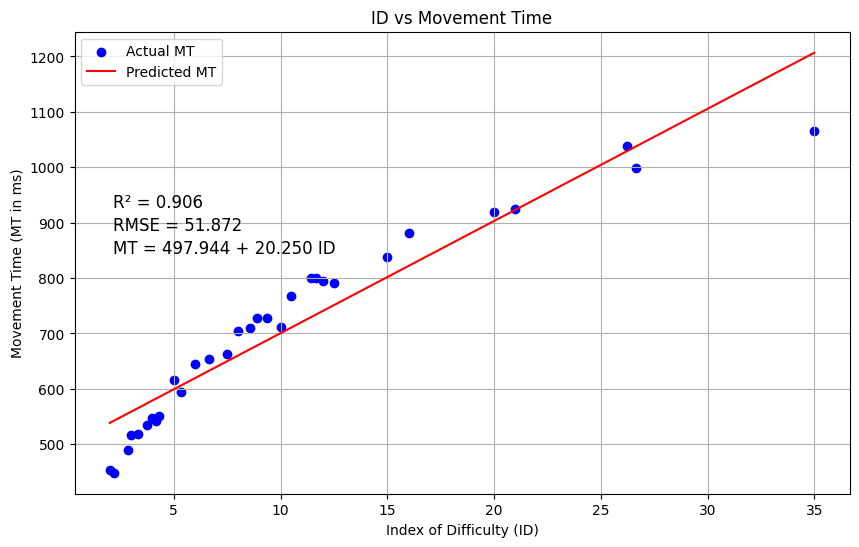

In [24]:
plt.figure(figsize=(10,6))

plt.scatter(X,y, label="Actual MT", color="Blue")

plt.plot(X,grouped_ID_df['predicted_MT'], label="Predicted MT", color = "Red")
plt.xlabel('Index of Difficulty (ID)')
plt.ylabel('Movement Time (MT in ms)')
plt.title('ID vs Movement Time')
plt.legend()
plt.grid()
plt.text(0.05, 0.65, f"R² = {r_squared_value:.3f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.05, 0.60, f"RMSE = {root_mean_squared_error_value:.3f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.05, 0.55, f"MT = {a:.3f} + {b:.3f} ID", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.show()

### Final Observation: Steering Law

The Linear Regression model gave the values of a=497.94 and 𝑏=20.25. The R² or the coefficient of determination is 0.90 which indicates that the model explains approximately 90% of the variance in the data and the RMSE is 51.87 and that is a moderate error relative to the scale of the dependent variable. Though the model captures a significant portion of the variance there can be improvement in R² and RMSE values